# Market microstructure and trade accounting

I use fixed seeds here so the numerical examples remain comparable when the implementation changes.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT/"src"))
pd.set_option("display.max_columns", 30)

I start with the difference between execution edge and later markout. The representative toxic-flow path makes it possible to see a fill earn spread immediately and then lose that edge after the mid-price moves.

In [2]:
from market_maker_lab.analysis import fill_intensity, expected_spread_rate
h=np.linspace(0.005,0.16,80)
frame=pd.DataFrame({"half_spread":h,"fill_intensity":[fill_intensity(x,90,18) for x in h],"gross_revenue_rate":[expected_spread_rate(x,90,18) for x in h]})
frame.loc[frame.gross_revenue_rate.idxmax()]

half_spread            0.056013
fill_intensity        32.837850
gross_revenue_rate     3.678671
Name: 26, dtype: float64

In [3]:
trades=pd.read_csv(ROOT/"outputs/data/representative_toxic_fixed_trades.csv")
trades[["side","price","quantity","quote_mid","immediate_spread_capture","post_trade_price_component","one_step_markout"]].head(10)

,side,price,quantity,quote_mid,immediate_spread_capture,post_trade_price_component,one_step_markout
0,buy,99.95,1.0,100.000000,0.050000,-0.016564,0.033436
1,buy,99.93,2.0,99.983436,0.106872,-0.232783,-0.125910
2,sell,99.92,1.0,99.867045,0.052955,-0.052255,0.000700
3,buy,99.86,1.0,99.919300,0.059300,-0.063555,-0.004255
4,buy,99.65,1.0,99.705432,0.055432,-0.191874,-0.136442
5,buy,99.64,2.0,99.695712,0.111425,-0.097452,0.013972
6,sell,99.57,1.0,99.514122,0.055878,-0.004513,0.051366
7,sell,99.38,1.0,99.321923,0.058077,0.101029,0.159106
8,buy,99.17,2.0,99.220894,0.101789,-0.040729,0.061060
9,sell,99.26,1.0,99.200530,0.059470,-0.258136,-0.198666


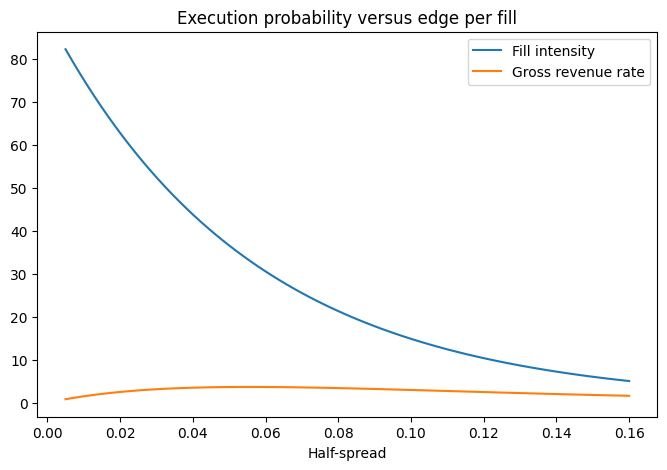

In [4]:
plt.figure(figsize=(8,5)); plt.plot(frame.half_spread,frame.fill_intensity,label="Fill intensity"); plt.plot(frame.half_spread,frame.gross_revenue_rate,label="Gross revenue rate"); plt.xlabel("Half-spread"); plt.legend(); plt.title("Execution probability versus edge per fill"); plt.show()